## Advance of Pandas Basics

## Essential Functionality

### Indexing, Selection, and Filtering

#### Indexing

In [6]:
import numpy as np
import pandas as pd

In [9]:
# indexing series dengan obj di pandas sangat mirip dengan indexing array di numpy tetapi lebih fleksibel
# dikarenakan kita tidak hanya bisa mengakses data dengan index integer, tetapi juga bisa mengakses data dengan index label
# pada aplikasinya, obj jarang digunakan, lebih sering digunakan loc dan iloc
# hal ini dikarenakan obj memiliki ambiguitas dalam mengakses apakah label atau posisi index
# misal:
### obj = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
# akses = obj[1] # apakah ini mengakses index ke-1 atau label '1'?
# print(akses)

# maka kita gunakan loc dan iloc
# dengan loc kita khusus mengakses dengan label index
obj = pd.Series(np.arange(5.), index=['a', 'b', 'c', 'd', 'e'])
# kita ingin mengakses label b,c,d
akses = obj.loc['b':'d'] # dalam pandas slicing bersifat inklusif, sehingga batas akhir akan diambil
print(akses)
# namu akan mendapat error jika loc berisi penunjuk integer, karena loc hanya menerima label index
akses1 = obj.loc[1:3] # akan error
print(akses1)


b    1.0
c    2.0
d    3.0
dtype: float64


TypeError: cannot do slice indexing on Index with these indexers [1] of type int

In [ ]:
# untuk mengakses dengan posisi index, kita gunakan iloc
akses2 = obj.iloc[[0, 2, 4]] # mengakses index ke-0, ke-2, dan ke-4
print(akses2)
# bila slicing, iloc bersifat eksklusif, sehingga batas akhir tidak akan diambil
akses3 = obj.iloc[1:4] # mengakses index ke-1, ke-2, dan ke-3
print(akses3)
# Jadi selalu gunakan loc untuk label dan iloc untuk integer index. Hal ini akan menghindari ambiguitas

a    0.0
c    2.0
e    4.0
dtype: float64
b    1.0
c    2.0
d    3.0
dtype: float64


In [19]:
# indexing pada dataframe akan mengambil 1 atau lebih kolom dengan nilai tunggal atau sequence
data = pd.DataFrame(np.arange(25).reshape((5,5)),
                    index=(['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi']),
                    columns = (['tahun', 'populasi', 'utang', 'pendapatan', 'pengeluaran']))
print(data)

print("\nindexing kolom tahun")
print(data['tahun']) # indexing kolom tahun

print("\nindexing kolom tahun dan populasi")
print(data[['tahun', 'populasi']]) # indexing kolom tahun dan populasi

# kita juga bisa mengakses baris dengan data[m:n] dimana m adalah index awal dan n adalah index akhir, tetapi ini tidak disarankan karena akan membingungkan
print("\nakses baris")
print(data[:3]) # mengakses baris ke-0, ke-1, dan ke-2 karena eksklusif slicing

           tahun  populasi  utang  pendapatan  pengeluaran
jakarta        0         1      2           3            4
bogor          5         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24

indexing kolom tahun
jakarta       0
bogor         5
depok        10
tangerang    15
bekasi       20
Name: tahun, dtype: int64

indexing kolom tahun dan populasi
           tahun  populasi
jakarta        0         1
bogor          5         6
depok         10        11
tangerang     15        16
bekasi        20        21

akses baris
         tahun  populasi  utang  pendapatan  pengeluaran
jakarta      0         1      2           3            4
bogor        5         6      7           8            9
depok       10        11     12          13           14


In [ ]:
# kita juga bisa menggunakan boolean indexing untuk mengakses baris atau kolom dengan kondisi tertentu
print("\nakses kolom pendapatan dengan kondisi > 10")
print(data[data['pendapatan'] > 10])

# atau masking dan menampilkan true/false
print("\nmasking data dengan kondisi > 10")
print(data > 10)

# 


akses kolom pendapatan dengan kondisi > 10
           tahun  populasi  utang  pendapatan  pengeluaran
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24

masking data dengan kondisi > 10
           tahun  populasi  utang  pendapatan  pengeluaran
jakarta    False     False  False       False        False
bogor      False     False  False       False        False
depok      False      True   True        True         True
tangerang   True      True   True        True         True
bekasi      True      True   True        True         True


#### Selection on DataFrame with loc and iloc

In [25]:
# DataFrame juga memiliki loc dan iloc untuk mengakses baris dan kolom dengan label index dan posisi integer index
print(data)

# untuk loc, bentuknya adalah data.loc[baris, kolom] dimana baris dan kolom bisa berupa label index, list label index, atau slicing label index
print("\nakses baris jakarta dan bogor, kolom tahun dan populasi")
print(data.loc[['jakarta', 'bogor'], ['tahun', 'populasi']])
# untuk iloc, bentuknya adalah data.iloc[baris, kolom] dimana baris dan kolom bisa berupa posisi integer index, list posisi integer index, atau slicing posisi integer index
print("\nakses baris ke-0 dan ke-1, kolom ke-0 dan ke-1")
print(data.iloc[[0, 1], [0, 1]])

           tahun  populasi  utang  pendapatan  pengeluaran
jakarta        0         1      2           3            4
bogor          5         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24

akses baris jakarta dan bogor, kolom tahun dan populasi
         tahun  populasi
jakarta      0         1
bogor        5         6

akses baris ke-0 dan ke-1, kolom ke-0 dan ke-1
         tahun  populasi
jakarta      0         1
bogor        5         6


In [27]:
# loc dan iloc bisa juga untuk slicing
print(data.loc[:'depok', :'utang']) # slicing baris jakarta sampai depok dan kolom tahun sampai utang

# atau dengan iloc
print(data.iloc[:, :3][data.utang > 5]) # di sini kita mengakses semua baris dan kolom ke-0 sampai ke-2, kemudian kita filter dengan kondisi utang > 5

         tahun  populasi  utang
jakarta      0         1      2
bogor        5         6      7
depok       10        11     12
           tahun  populasi  utang
bogor          5         6      7
depok         10        11     12
tangerang     15        16     17
bekasi        20        21     22


In [28]:
# array boolean hanya bisa dengan loc tidak bisa dengan iloc, karena iloc hanya menerima integer index
print(data.loc[data.utang >= 5]) # disini kita mengakses semua baris dan kolom, kemudian kita filter dengan kondisi utang >= 5

           tahun  populasi  utang  pendapatan  pengeluaran
bogor          5         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24


#### berikut rumus lengkapnya:
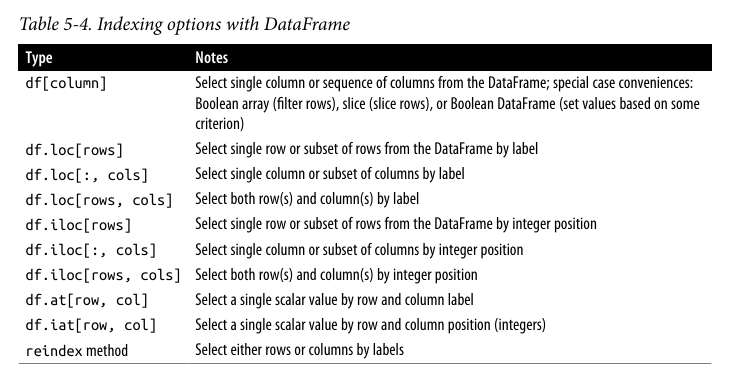

In [35]:
# selalu gunakan iloc untuk integer index dan loc untuk label index
# dan hindari chaining indexing karena akan membingungkan
# misal:
#data.loc[data.tahun == 5]['tahun']= 6 # ini akan error karena kita mengakses kolom tahun setelah memfilter baris dengan kondisi utang >= 5
# solusinya gunakan satu operasi dengan loc
data.loc[data.tahun == 5, 'tahun']= 6 # ini akan berhasil karena kita mengakses kolom tahun dan memfilter baris dengan kondisi utang >= 5 dalam satu operasi
print(data)

           tahun  populasi  utang  pendapatan  pengeluaran
jakarta        0         1      2           3            4
bogor          6         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24


### Arithmetic and Data Alignment

In [39]:
# aritmatika antar objek di pandas akan secara otomatis menyesuaikan index, sehingga jika index tidak sama maka akan menghasilkan NaN
# untuk mengisi NaN, kita bisa menggunakan fill_value pada operasi aritmatika
# misal kita punya dua dataframe dengan index yang berbeda
df1 = pd.DataFrame(np.arange(9.).reshape((3,3)), columns=list('abc'), index=['jakarta', 'bogor', 'depok'])
print(df1)
df2 = pd.DataFrame(np.arange(12.).reshape((4,3)), columns=list('abc'), index=['jakarta', 'bogor', 'depok', 'tangerang'])
print(df2)
print(df1+df2) # akan menghasilkan NaN pada baris tangerang karena tidak ada di df1


           a    b    c
jakarta  0.0  1.0  2.0
bogor    3.0  4.0  5.0
depok    6.0  7.0  8.0
             a     b     c
jakarta    0.0   1.0   2.0
bogor      3.0   4.0   5.0
depok      6.0   7.0   8.0
tangerang  9.0  10.0  11.0
              a     b     c
bogor       6.0   8.0  10.0
depok      12.0  14.0  16.0
jakarta     0.0   2.0   4.0
tangerang   NaN   NaN   NaN


In [ ]:
# untuk mengatasi hal ini, pandas menyediakan method add, sub, mul, div, dan mod yang memiliki parameter fill_value untuk mengisi NaN
#bentuk argumennya: obj1.method(obj2, fill_value=0)
print(df1.add(df2, fill_value=0)) # akan mengisi NaN dengan 0 pada baris tangerang sehingga hasilnya akan menjadi 0 + 9 = 9 pada baris tangerang

              a     b     c
bogor       6.0   8.0  10.0
depok      12.0  14.0  16.0
jakarta     0.0   2.0   4.0
tangerang   9.0  10.0  11.0


#### Berikut rumus lengkapnya:
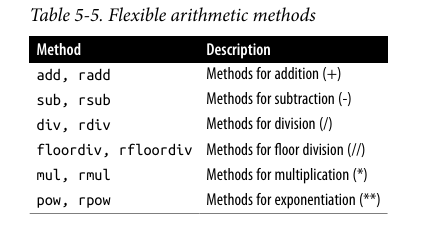

#### Operations between DataFrame and Series

In [43]:
# hampir sama dengan numpy array, operasi aritmatika antara array berbeda shape akan menghasilkan broadcasting
# pada pandas, operasi aritmatika antara dataframe dan series akan menghasilkan broadcasting juga, tetapi dengan aturan yang berbeda
# jika sesuai dengan index, maka akan dilakukan operasi aritmatika sesuai index, jika tidak sesuai maka akan menghasilkan NaN
frame = pd.DataFrame(np.arange(9.).reshape((3,3)), columns=list('abc'), index=['jakarta', 'bogor', 'depok'])
print(frame)
series = frame.iloc[0] # mengambil baris pertama sebagai series
print(series)
# dengan aritmatika dasar, pandas akan mencocokan index series dengan index dataframe
print(frame - series) # akan mengurangi setiap baris dataframe dengan series sesuai indexnya
series2 = pd.Series(np.arange(3.), index=['a', 'c', 'd']) # series ini memiliki index yang berbeda dengan dataframe
print(frame - series2) # akan menghasilkan NaN pada kolom b dan d

           a    b    c
jakarta  0.0  1.0  2.0
bogor    3.0  4.0  5.0
depok    6.0  7.0  8.0
a    0.0
b    1.0
c    2.0
Name: jakarta, dtype: float64
           a    b    c
jakarta  0.0  0.0  0.0
bogor    3.0  3.0  3.0
depok    6.0  6.0  6.0
           a   b    c   d
jakarta  0.0 NaN  1.0 NaN
bogor    3.0 NaN  4.0 NaN
depok    6.0 NaN  7.0 NaN


In [45]:
# bila ingin di broadcasting dengan kolom, kita bisa menggunakan operasi aritmatika dengan axis=1/index
series3 = frame['b'] # mengambil kolom b sebagai series
print(frame.sub(series3, axis='index')) # akan mengurangi setiap kolom dataframe dengan series sesuai indexnya
print(frame.sub(series3, axis='columns')) # akan mengurangi setiap baris dataframe dengan series sesuai indexnya

           a    b    c
jakarta -1.0  0.0  1.0
bogor   -1.0  0.0  1.0
depok   -1.0  0.0  1.0
          a   b  bogor   c  depok  jakarta
jakarta NaN NaN    NaN NaN    NaN      NaN
bogor   NaN NaN    NaN NaN    NaN      NaN
depok   NaN NaN    NaN NaN    NaN      NaN


### Function Application and Mapping

In [52]:
# ufuncs numpy juga berlaku pada pandas
# fungsi python juga bisa diaplikasikan pada pandas
# namun pandas menyediakan fungsi kustom untuk mengaplikasikan fungsi pada dataframe dan series, yaitu apply, applymap, dan map

#misal kita punya dataframe dengan nilai random
frame = pd.DataFrame(np.random.standard_normal((4,3)), columns=list('abc'), index=['jakarta', 'bogor', 'depok', 'tangerang'])
print(frame)
#dan punya fungsi kustom untuk menghitung range (selisih nilai max dan min)
def my_range(x):
    return x.max() - x.min()
#maka kita gunakan apply untuk menghitung range pada setiap kolom
print("\nmenghitung range pada setiap kolom")
print(frame.apply(my_range)) # akan mengembalikan series dengan index kolom dan nilai range
#jika kita menambahkan axis='columns', maka akan menghitung range pada setiap baris
print("\nmenghitung range pada setiap baris")
print(frame.apply(my_range, axis='columns')) # akan mengembalikan series dengan index baris dan nilai range

#jika ada fungsi yang beroperasi di tiap elemen. maka kita gunakan amap untuk versi pandas 2.1.0 ke atas
def my_func(x):
    return f"{x:.2f}" # mengubah nilai menjadi string dengan 2 angka dibelakang koma
print("\nmengubah nilai menjadi string dengan 2 angka dibelakang koma")
print(frame.map(my_func)) # akan mengembalikan dataframe dengan nilai string
# bila dalam series
print("\nmengubah nilai menjadi string dengan 2 angka dibelakang koma pada series")
print(frame['b'].map(my_func)) # akan mengembalikan series dengan nilai string

                  a         b         c
jakarta   -0.723455  2.609672 -0.928403
bogor     -0.731360 -1.739886  1.046136
depok     -1.551954  0.826015  0.683589
tangerang -0.570510 -1.954995 -0.188863

menghitung range pada setiap kolom
a    0.981444
b    4.564667
c    1.974539
dtype: float64

menghitung range pada setiap baris
jakarta      3.538075
bogor        2.786022
depok        2.377969
tangerang    1.766132
dtype: float64

mengubah nilai menjadi string dengan 2 angka dibelakang koma
               a      b      c
jakarta    -0.72   2.61  -0.93
bogor      -0.73  -1.74   1.05
depok      -1.55   0.83   0.68
tangerang  -0.57  -1.95  -0.19

mengubah nilai menjadi string dengan 2 angka dibelakang koma pada series
jakarta       2.61
bogor        -1.74
depok         0.83
tangerang    -1.95
Name: b, dtype: str


### Sorting and Ranking

#### Sorting

In [60]:
# Sorting atau pengurutan memili ki dua metode, yaitu sort_index dan sort_values
# misal kita punya series dan dataframe dengan index dan kolom yang tidak berurutan
series1 = pd.Series([1, 3, 2], index=['jakarta', 'bogor', 'depok'])
print(series1)
df1 = pd.DataFrame(np.arange(16.).reshape((4,4)), index=['jakarta', 'bogor', 'depok', 'tangerang'], columns=list('cbad'))
print(df1)

# dengan sort_index, kita bisa mengurutkan index pada series
print("\nmengurutkan index pada series")
print(series1.sort_index())

# dengan dataframe, kita bisa memilih salah satu axis untuk diurutkan, baik baris(index) atau kolom
print("\nmengurutkan baris pada dataframe")
print(df1.sort_index(axis=0)) # mengurutkan baris
print("\nmengurutkan kolom pada dataframe")
print(df1.sort_index(axis=1)) # mengurutkan kolom

jakarta    1
bogor      3
depok      2
dtype: int64
              c     b     a     d
jakarta     0.0   1.0   2.0   3.0
bogor       4.0   5.0   6.0   7.0
depok       8.0   9.0  10.0  11.0
tangerang  12.0  13.0  14.0  15.0

mengurutkan index pada series
bogor      3
depok      2
jakarta    1
dtype: int64

mengurutkan baris pada dataframe
              c     b     a     d
bogor       4.0   5.0   6.0   7.0
depok       8.0   9.0  10.0  11.0
jakarta     0.0   1.0   2.0   3.0
tangerang  12.0  13.0  14.0  15.0

mengurutkan kolom pada dataframe
              a     b     c     d
jakarta     2.0   1.0   0.0   3.0
bogor       6.0   5.0   4.0   7.0
depok      10.0   9.0   8.0  11.0
tangerang  14.0  13.0  12.0  15.0


In [68]:
# untuk sorting berdasarkan nilai, kita gunakan sort_values
df2 = frame = pd.DataFrame({"b": [4, 7, -3, 2], "a": [0, 1, 0, 1]})
print("\nmengurutkan series berdasarkan nilai")
print(series1.sort_values()) # mengurutkan series berdasarkan nilai
print("\nmengurutkan dataframe berdasarkan kolom b")
print(df2.sort_values(by='b')) # mengurutkan dataframe berdasarkan kolom b



mengurutkan series berdasarkan nilai
jakarta    1
depok      2
bogor      3
dtype: int64

mengurutkan dataframe berdasarkan kolom b
   b  a
2 -3  0
3  2  1
0  4  0
1  7  1


#### Ranking

In [ ]:
# ranking akan mengurutkan semua titik data dalam series atau dataframe, dan memberikan peringkat pada setiap titik data
obj = pd.Series([7, -5, 7, 4, 2, 0, 4])
print(obj.rank()) #output berbentuk: index : nilai peringkat

0    6.5
1    1.0
2    6.5
3    4.5
4    3.0
5    2.0
6    4.5
dtype: float64


In [70]:
# ada beberapa metode tie-breaking untuk ranking, yaitu average, min, max, first, dan dense, pada default, ranking menggunakan metode average
print("\nmetode tie-breaking first")
print(obj.rank(method='first'))


metode tie-breaking first
0    6.0
1    1.0
2    7.0
3    4.0
4    3.0
5    2.0
6    5.0
dtype: float64


##### berikut penjelasan lengkap tiap metode tie-breaking:
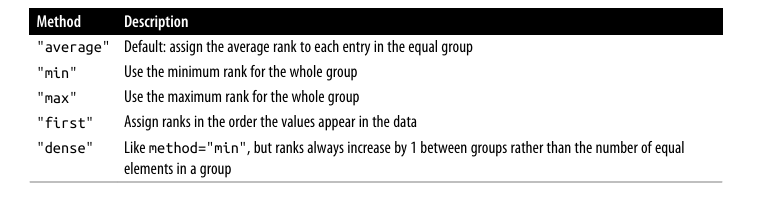

In [71]:
# bila ingin diurutkan menurun, kita bisa menambahkan parameter ascending=False
print("\nmetode tie-breaking first dengan urutan menurun")
print(obj.rank(method='first', ascending=False))


metode tie-breaking first dengan urutan menurun
0    1.0
1    7.0
2    2.0
3    3.0
4    5.0
5    6.0
6    4.0
dtype: float64


### Axis Indexes with Duplicate Labels

In [76]:
# dengan method is_unique, kita bisa mengecek apakah index pada series atau dataframe unik atau tidak
obj = pd.Series(np.arange(5), index=["a", "a", "b", "b", "c"])
print(obj)
print(obj.index.is_unique) # akan mengembalikan False karena index tidak unik

a    0
a    1
b    2
b    3
c    4
dtype: int64
False


## Summarizing and Computing Descriptive Statistics

###  Descriptive and summary statistics
#### objek pandas dilengkapi dengan beberapa fungsi statistik yang bisa digunakan untuk meringkas/mereduksi data

In [ ]:
# misal kita punya dataframe
df1 = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                    [np.nan, np.nan], [0.75, -1.3]],
                    index=["a", "b", "c", "d"],
                    columns=["one", "two"])
print(df1)
# objek pandas juga dilengakapi penanganan missing data(naN) dengan mengskipnya.
print("\nmenghitung total nilai pada dataframe")
print(df1.sum()) # menampilkan series dengan index kolom dan nilai total, secara default axis=0(baris)
# jika ingin menghitung total nilai pada setiap baris, kita bisa menambahkan parameter axis=1
print("\nmenghitung total nilai pada setiap baris")
print(df1.sum(axis='columns')) # menampilkan series dengan index baris dan nilai total
#bila na ingin dimasukkan dalam perhitungan, kita bisa menambahkan parameter skipna=False
print("\nmenghitung total nilai pada dataframe dengan skipna=False")
print(df1.sum(skipna=False)) # akan menghasilkan NaN pada kolom one karena ada nilai NaN pada kolom two
# beberapa agregasi seperti mean membutuhkan setidaknya satu nilai non-NaN untuk menghasilkan nilai, sehingga jika semua nilai NaN maka akan menghasilkan NaN
print("\nmenghitung rata-rata nilai pada dataframe")
print(df1.mean(axis='columns'))

    one  two
a  1.40  NaN
b  7.10 -4.5
c   NaN  NaN
d  0.75 -1.3

menghitung total nilai pada dataframe
one    9.25
two   -5.80
dtype: float64

menghitung total nilai pada setiap baris
a    1.40
b    2.60
c    0.00
d   -0.55
dtype: float64

menghitung total nilai pada dataframe dengan skipna=False
one   NaN
two   NaN
dtype: float64

menghitung rata-rata nilai pada dataframe
a    1.400
b    1.300
c      NaN
d   -0.275
dtype: float64


In [86]:
# beberapa metode memberikan nilai index, misal idxmin dan idxmax akan mengembalikan index dari nilai minimum dan maksimum
print("\nmenghitung index dari nilai minimum dan maksimum pada dataframe")
print(df1.idxmin()) # akan mengembalikan series dengan index kolom dan nilai
print(df1.idxmax()) # akan mengembalikan series dengan index kolom dan nilai
# ada metode accumulation, misal cumsum dan cumprod yang akan mengembalikan nilai akumulasi dari setiap titik data
print("\nmenghitung akumulasi nilai pada dataframe")
print(df1.cumsum()) # akan mengembalikan dataframe dengan nilai akumulasi pada
# ada juga describe yang akan memberikan ringkasan statistik dari dataframe atau series baik numerik maupun non-numerik
print("\nmenghitung ringkasan statistik pada dataframe numerik")
print(df1.describe()) # akan mengembalikan dataframe dengan ringkasan statistik pada setiap kolom
# misal kita punya series non-numerik
obj = pd.Series(["a", "a", "b", "c"] * 4)
print("\nmenghitung ringkasan statistik pada series non-numerik")
print(obj.describe()) # akan mengembalikan series dengan ringkasan statistik pada series non-numerik



menghitung index dari nilai minimum dan maksimum pada dataframe
one    d
two    b
dtype: str
one    b
two    d
dtype: str

menghitung akumulasi nilai pada dataframe
    one  two
a  1.40  NaN
b  8.50 -4.5
c   NaN  NaN
d  9.25 -5.8

menghitung ringkasan statistik pada dataframe numerik
            one       two
count  3.000000  2.000000
mean   3.083333 -2.900000
std    3.493685  2.262742
min    0.750000 -4.500000
25%    1.075000 -3.700000
50%    1.400000 -2.900000
75%    4.250000 -2.100000
max    7.100000 -1.300000

menghitung ringkasan statistik pada series non-numerik
count     16
unique     3
top        a
freq       8
dtype: object


#### berikut rumus lengkapnya:
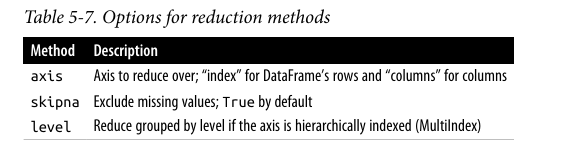
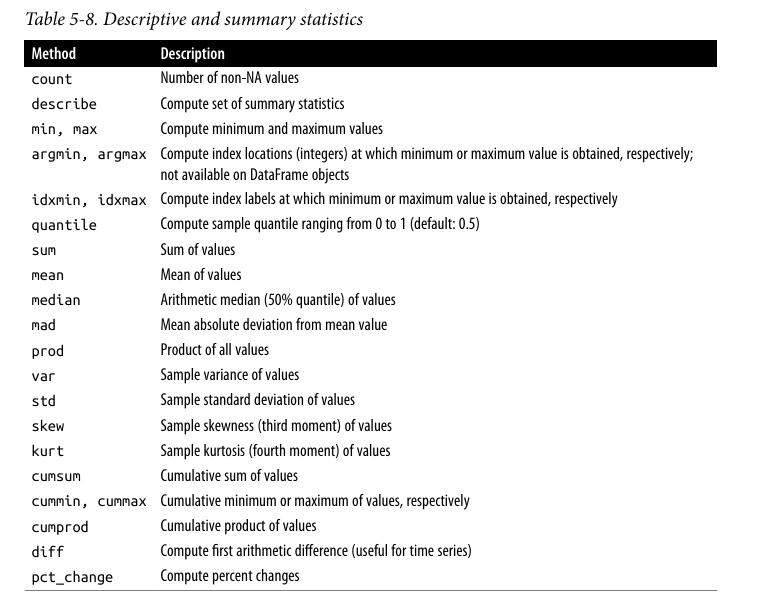

### Correlation and Covariance

Pandas menyediakan fungsi untuk menghitung korelasi dan kovarians antar kolom pada DataFrame. Korelasi mengukur sejauh mana dua variabel bergerak bersama, sedangkan kovarians mengukur arah hubungan antara dua variabel.

kita juga bisa membuat matriks korelasi dan kovarians antar kolom pada DataFrame dengan menggunakan method corr() dan cov().

kita juga bisa melakukan cor dan cov lintas objek dengan menggunakan method corrwith() ataupun covwith().

### Unique Values, Value Counts, and Membership

In [96]:
# unique values akan memberi array nilai unik pada series atau dataframe
obj = pd.Series(['c', 'a', 'd', 'a', 'a', 'b', 'b', 'c', 'c'])
print("\nmenghitung nilai unik pada series")
uniques = obj.unique() # akan mengembalikan array dengan nilai unik
print(uniques)
# value_counts akan memberi frekuensen dari setiap nilai unik pada series atau dataframe
print("\nmenghitung frekuensi nilai unik pada series")
print(obj.value_counts()) # akan mengembalikan series dengan index nilai unik dan nilai frekuensi
# dengan isin kita diberi masking untuk mengecek apakah nilai pada series atau dataframe ada di dalam list atau array tertentu
print("\nmenghitung masking nilai unik pada series")
mask = obj.isin(['b', 'c']) # akan mengembalikan series dengan index dan nilai True/False
print(mask)
# index.get_indexer akan mengembalikan posisi index dari nilai unik pada series atau dataframe
to_match = pd.Series(["c", "a", "b", "b", "c", "a"])
unique_vals = pd.Series(["c", "b", "a"])
print("\nmenghitung posisi index dari nilai unik pada series")
indices = pd.Index(unique_vals).get_indexer(to_match) # akan mengembalikan array dengan posisi index dari nilai unik
print(indices)


menghitung nilai unik pada series
<StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str

menghitung frekuensi nilai unik pada series
c    3
a    3
b    2
d    1
Name: count, dtype: int64

menghitung masking nilai unik pada series
0     True
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
dtype: bool

menghitung posisi index dari nilai unik pada series
[0 2 1 1 0 2]


#### berikut tabel penjelasan lengkap tiap method:
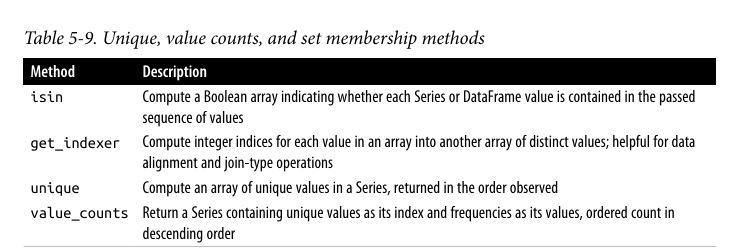